In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import astropy.constants as c
import astropy.units as u
import matplotlib.pyplot as plt
from torch.utils.data import random_split
from BPNN import VectorScalarDataset, ScalarNN, BPNN

def cd_sed(nu, Beta, T, a=1):
    nu_c = 545 #GHz
    h_over_k = (c.h/c.k_B/(1*u.K)).to('GHz-1').value
    return a*(nu/nu_c)**(Beta+1)*(np.exp(h_over_k*nu_c/T) - 1)/(np.exp(h_over_k*nu/T) - 1)

def integral(bp_shift, Beta, T, bp_dat):
    return np.sum(bp_dat[1]*cd_sed(bp_dat[0]+bp_shift, Beta, T))

In [2]:
# Device configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_data = torch.load("dataset_train.pt")
test_data = torch.load("dataset_val.pt")

y_mean = train_data["y"].mean()
y_std  = train_data["y"].std()

y_mean_test = test_data["y"].mean()
y_std_test  = test_data["y"].std()

print("TRAINING DATASET, parameters order:")
print(f"Bandpass shift: mean={train_data['X'][:,0].mean():.2f}, std={train_data['X'][:,0].std():.2f}")
print(f"          Beta: mean={train_data['X'][:,1].mean():.2f}, std={train_data['X'][:,1].std():.2f}")
print(f"             T: mean={train_data['X'][:,2].mean():.2f}, std={train_data['X'][:,2].std():.2f}")
print(f"y mean: {y_mean:.2f}")
print(f"y std:  {y_std:.2f}")

# Normalize
y_train_norm = (train_data["y"] - y_mean) / y_std
y_test_norm = (test_data["y"] - y_mean) / y_std

dataset = VectorScalarDataset(train_data["X"], y_train_norm)
test_dataset = VectorScalarDataset(test_data["X"], test_data["y"])

total = len(dataset)
val_size   = int(0.2 * total)
train_size = total - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader  = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

model = ScalarNN() #.to(device)

print("MODEL:")
print(model)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total}")
print(f"Total FLOPs: {model.flops}")

criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) #, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=3, verbose=True
# )

TRAINING DATASET, parameters order:
Bandpass shift: mean=-0.29, std=5.79
          Beta: mean=1.90, std=0.17
             T: mean=12.00, std=1.16
y mean: 867.58
y std:  5.39
MODEL:
ScalarNN(
  (in_l): Linear(in_features=3, out_features=8, bias=True)
  (hl_1): Linear(in_features=8, out_features=8, bias=True)
  (hl_2): Linear(in_features=8, out_features=8, bias=True)
  (hl_3): Linear(in_features=8, out_features=8, bias=True)
  (out_l): Linear(in_features=8, out_features=1, bias=True)
)
Trainable parameters: 257
Total FLOPs: 448


In [3]:
#Train
if True:
    num_epochs = 50
    avg_t_loss_s = np.zeros(num_epochs)
    avg_v_loss_s = np.zeros(num_epochs)
    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch #.to(device)      # move inputs to GPU
            y_batch = y_batch #.to(device)      # move targets to GPU

            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * len(y_batch)

        # --- Validation ---
        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch #.to(device)  # move inputs to GPU
                y_batch = y_batch #.to(device)  # move targets to GPU

                preds = model(X_batch)
                loss  = criterion(preds, y_batch)
                total_val_loss += loss.item() * len(y_batch)

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        avg_val_loss   = total_val_loss   / len(val_loader.dataset)
        avg_t_loss_s[epoch] = avg_train_loss
        avg_v_loss_s[epoch] = avg_val_loss
        print(f"Epoch {epoch+1}: train={avg_train_loss:.4f}  val={avg_val_loss:.4f}")


Epoch 1: train=0.2260  val=0.0764
Epoch 2: train=0.0444  val=0.0269
Epoch 3: train=0.0194  val=0.0159
Epoch 4: train=0.0141  val=0.0119
Epoch 5: train=0.0105  val=0.0091
Epoch 6: train=0.0086  val=0.0079
Epoch 7: train=0.0078  val=0.0075
Epoch 8: train=0.0074  val=0.0071
Epoch 9: train=0.0072  val=0.0070
Epoch 10: train=0.0072  val=0.0071
Epoch 11: train=0.0071  val=0.0070
Epoch 12: train=0.0071  val=0.0070
Epoch 13: train=0.0070  val=0.0070
Epoch 14: train=0.0070  val=0.0068
Epoch 15: train=0.0069  val=0.0067
Epoch 16: train=0.0067  val=0.0067
Epoch 17: train=0.0063  val=0.0061
Epoch 18: train=0.0061  val=0.0059
Epoch 19: train=0.0060  val=0.0063
Epoch 20: train=0.0060  val=0.0059
Epoch 21: train=0.0060  val=0.0064
Epoch 22: train=0.0060  val=0.0058
Epoch 23: train=0.0059  val=0.0058
Epoch 24: train=0.0059  val=0.0058
Epoch 25: train=0.0059  val=0.0058
Epoch 26: train=0.0059  val=0.0057
Epoch 27: train=0.0059  val=0.0060
Epoch 28: train=0.0059  val=0.0062
Epoch 29: train=0.0058  val=0

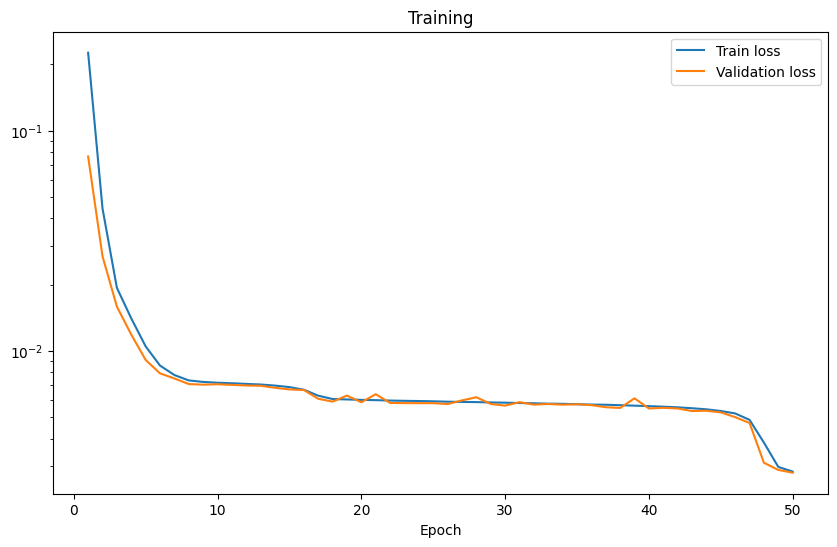

In [ ]:
plt.figure(figsize=(10,6))
plt.title("Training")
plt.plot(np.arange(1, num_epochs+1), avg_t_loss_s, label="Train loss")
plt.plot(np.arange(1, num_epochs+1), avg_v_loss_s, label="Validation loss")
plt.yscale('log')
plt.xlabel("Epoch")
plt.savefig("training.png")
plt.legend()
plt.close

if False:
    torch.save({
        'model_state_dict': model.state_dict(),
        'y_mean': y_mean,
        'y_std':  y_std,
        }, 'bandpass_NN_v3.pth')

In [ ]:
#Evaluation on the Test Set

model = ScalarNN()    # instantiate architecture first
model_setup_dict = torch.load('bandpass_NN_v3.pth', map_location=device)
model.load_state_dict(model_setup_dict['model_state_dict'])
y_std, y_mean = model_setup_dict['y_std'], model_setup_dict['y_mean'] 
model #.to(device)
model.eval()


NeuralNet(
  (in_l): Linear(in_features=3, out_features=8, bias=True)
  (hl_1): Linear(in_features=8, out_features=8, bias=True)
  (hl_2): Linear(in_features=8, out_features=8, bias=True)
  (hl_3): Linear(in_features=8, out_features=8, bias=True)
  (out_l): Linear(in_features=8, out_features=1, bias=True)
)

In [19]:
"model_state_dict" in model_setup_dict

True

In [26]:
with torch.no_grad():
    # Single sample
    errs = []
    total_val_loss = 0
    for X_batch, y_batch in test_loader:
        X_batch = X_batch #.to(device)  # move inputs to GPU
        y_batch = y_batch #.to(device)  # move targets to GPU
        X_b0 = X_batch[0]
        pred_norm = model(X_b0)
        pred = pred_norm * y_std + y_mean           # denormalize output
        err = abs((pred - y_batch[0].item()))/y_batch[0].item()
        print(f"Params: [{X_b0[0]}, {X_b0[1]}, {X_b0[2]}], Preds = {pred.item():.4f}, True = {y_batch[0].item():.4f}, err = {err}")
        errs.append(err)
        loss  = criterion(pred, y_batch)
        total_val_loss += loss.item() * len(y_batch)

Params: [-10.0, 1.600000023841858, 10.0], Preds = 866.2864, True = 863.6838, err = 0.003013405903571548
Params: [-10.0, 1.6571428775787354, 13.809523582458496], Preds = 866.3024, True = 861.8459, err = 0.00517085291989339
Params: [-10.0, 1.7428570985794067, 13.428571701049805], Preds = 866.2978, True = 861.5145, err = 0.005552192447907686
Params: [-10.0, 1.8285714387893677, 13.047618865966797], Preds = 866.2932, True = 861.1963, err = 0.005918426184812059
Params: [-10.0, 1.914285659790039, 12.666666984558105], Preds = 866.2886, True = 860.8893, err = 0.006271732070967406
Params: [-10.0, 2.0, 12.285714149475098], Preds = 866.2840, True = 860.5916, err = 0.0066145099496082195
Params: [-10.0, 2.085714340209961, 11.904762268066406], Preds = 866.2794, True = 860.3010, err = 0.006949166524268774
Params: [-10.0, 2.171428680419922, 11.523809432983398], Preds = 866.2748, True = 860.0154, err = 0.007278187336320309
Params: [-9.047618865966797, 1.6285713911056519, 11.142857551574707], Preds = 866

/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([24])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


/tmp/ipykernel_19048/3159281034.py:54: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


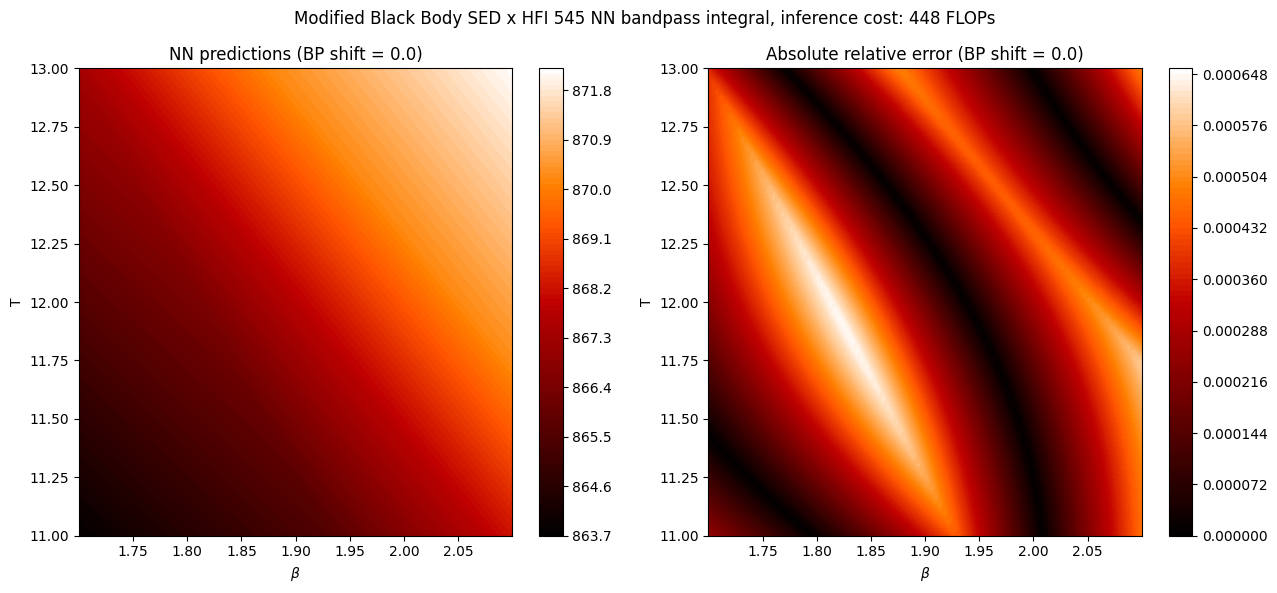

In [46]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s_fixed = 0.0 

grid_b, grid_t = torch.meshgrid(beta_s, t_s, indexing='ij')

X_grid = torch.stack([
    torch.full((N_vals*N_vals,), bp_s_fixed),
    grid_b.flatten(),
    grid_t.flatten()
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
all_true = []
with torch.no_grad():
    preds_grid = model(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))
trues_grid=np.array(all_true).reshape((N_vals,N_vals))

#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.flops} FLOPs")
cf = ax[0].contourf(
    grid_b.numpy(),         # x axis  shape: (100, 100)
    grid_t.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel(r'$\beta$')
ax[0].set_ylabel('T')
ax[0].set_title(f'NN predictions (BP shift = {bp_s_fixed})')

cf = ax[1].contourf(
    grid_b.numpy(),       # x axis  shape: (100, 100)
    grid_t.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel(r'$\beta$')
ax[1].set_ylabel('T')
ax[1].set_title(f'Absolute relative error (BP shift = {bp_s_fixed})')
plt.tight_layout()
plt.show()

/tmp/ipykernel_19048/2685985339.py:56: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


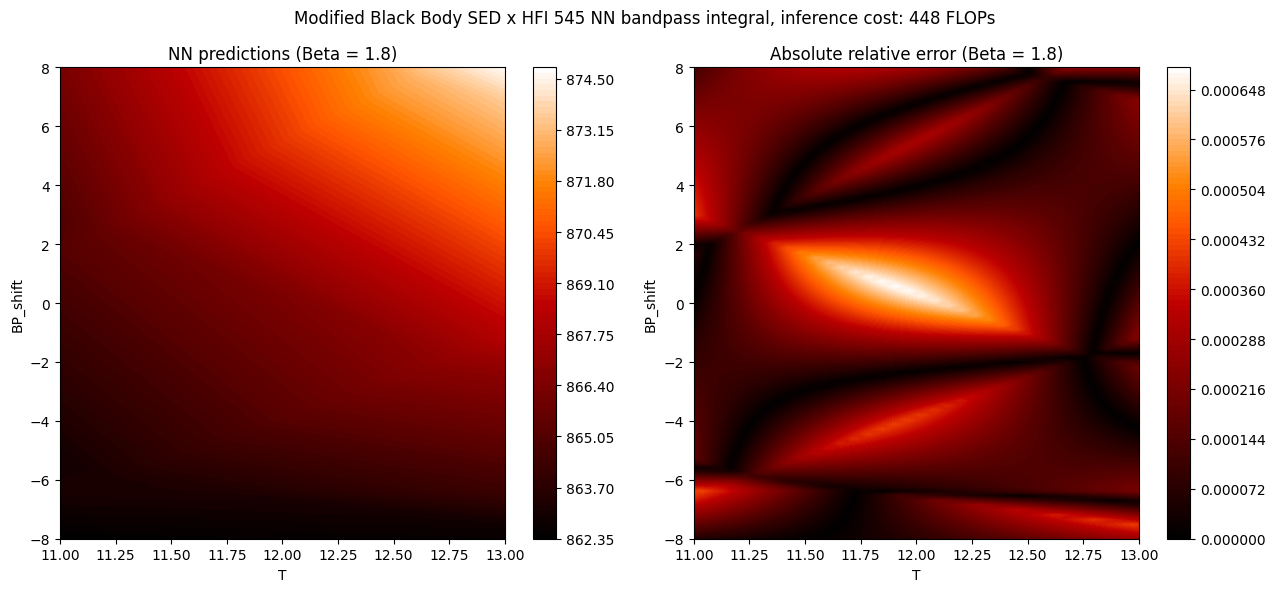

In [47]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
beta_fixed = 1.8
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s = torch.linspace(samp_intervals["BP_shift"][0], samp_intervals["BP_shift"][1], N_vals)

grid_t, grid_bps = torch.meshgrid(t_s, bp_s, indexing='ij')

X_grid = torch.stack([
    grid_bps.flatten(),
    torch.full((N_vals*N_vals,), beta_fixed),
    grid_t.flatten()
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
all_true = []
with torch.no_grad():
    preds_grid = model(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))

trues_grid=np.array(all_true).reshape((N_vals,N_vals))


#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.flops} FLOPs")
cf = ax[0].contourf(
    grid_t.numpy(),         # x axis  shape: (100, 100)
    grid_bps.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel('T')
ax[0].set_ylabel('BP_shift')
ax[0].set_title(f'NN predictions (Beta = {beta_fixed})')

cf = ax[1].contourf(
    grid_t.numpy(),       # x axis  shape: (100, 100)
    grid_bps.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel('T')
ax[1].set_ylabel('BP_shift')
ax[1].set_title(f'Absolute relative error (Beta = {beta_fixed})')
plt.tight_layout()
plt.show()

/tmp/ipykernel_19048/2198155001.py:54: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


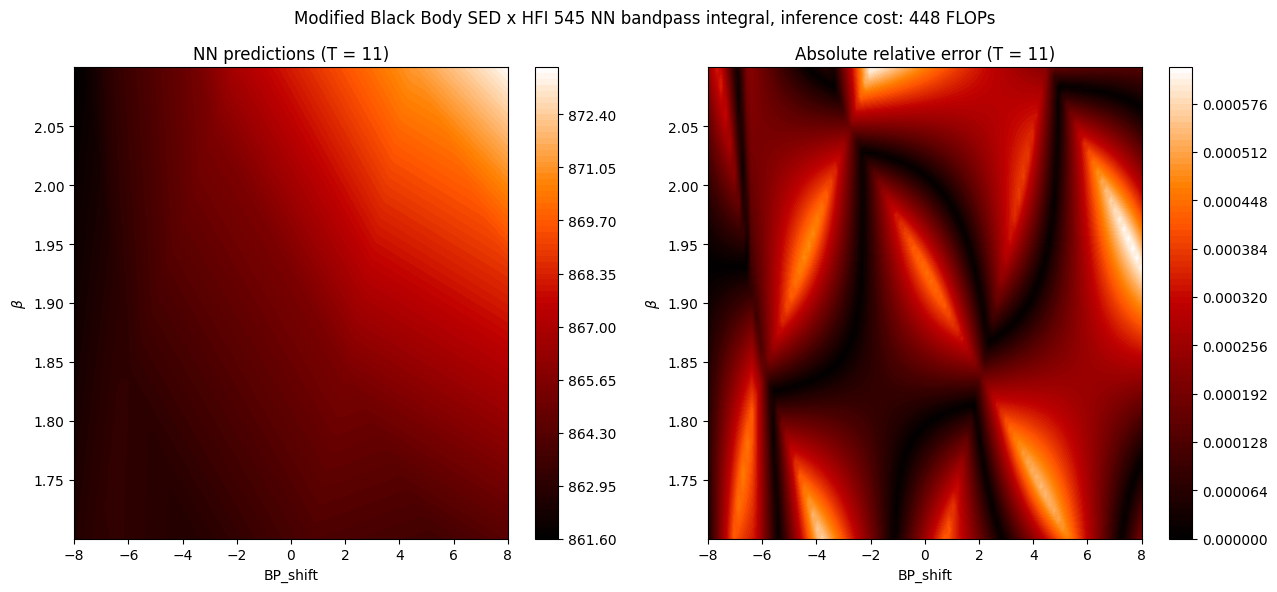

In [48]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
T_fixed = 11
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
bp_s = torch.linspace(samp_intervals["BP_shift"][0], samp_intervals["BP_shift"][1], N_vals)

grid_bps, grid_beta = torch.meshgrid(bp_s, beta_s, indexing='ij')

X_grid = torch.stack([
    grid_bps.flatten(),
    grid_beta.flatten(),
    torch.full((N_vals*N_vals,), T_fixed)
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
all_true = []
with torch.no_grad():
    preds_grid = model(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))
trues_grid=np.array(all_true).reshape((N_vals,N_vals))

#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.flops} FLOPs")
cf = ax[0].contourf(
    grid_bps.numpy(),         # x axis  shape: (100, 100)
    grid_beta.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel('BP_shift')
ax[0].set_ylabel(r'$\beta$')
ax[0].set_title(f'NN predictions (T = {T_fixed})')

cf = ax[1].contourf(
    grid_bps.numpy(),       # x axis  shape: (100, 100)
    grid_beta.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel('BP_shift')
ax[1].set_ylabel(r'$\beta$')
ax[1].set_title(f'Absolute relative error (T = {T_fixed})')
plt.tight_layout()
plt.show()

In [3]:
BPmodel = BPNN()
BPmodel.train(dataset)

Epoch 1: train=0.1639  val=0.0541
Epoch 2: train=0.0153  val=0.0066
Epoch 3: train=0.0051  val=0.0043
Epoch 4: train=0.0041  val=0.0039
Epoch 5: train=0.0036  val=0.0034
Epoch 6: train=0.0032  val=0.0032
Epoch 7: train=0.0029  val=0.0030
Epoch 8: train=0.0027  val=0.0028
Epoch 9: train=0.0025  val=0.0025
Epoch 10: train=0.0024  val=0.0022
Epoch 11: train=0.0022  val=0.0022
Epoch 12: train=0.0021  val=0.0020
Epoch 13: train=0.0021  val=0.0020
Epoch 14: train=0.0020  val=0.0020
Epoch 15: train=0.0020  val=0.0019
Epoch 16: train=0.0020  val=0.0019
Epoch 17: train=0.0019  val=0.0020
Epoch 18: train=0.0019  val=0.0019
Epoch 19: train=0.0019  val=0.0018
Epoch 20: train=0.0019  val=0.0022
Epoch 21: train=0.0019  val=0.0018
Epoch 22: train=0.0018  val=0.0021
Epoch 23: train=0.0018  val=0.0017
Epoch 24: train=0.0018  val=0.0018
Epoch 25: train=0.0018  val=0.0017
Epoch 26: train=0.0017  val=0.0017
Epoch 27: train=0.0017  val=0.0017
Epoch 28: train=0.0017  val=0.0017
Epoch 29: train=0.0017  val=0

In [6]:
BPmodel.save('bandpass_NN_v2.pth')

In [3]:
BP_loaded = BPNN()
BP_loaded.load('bandpass_NN_v2.pth')

In [9]:
errs = []
total_val_loss = 0
for X_batch, y_batch in test_loader:
    X_batch = X_batch #.to(device)  # move inputs to GPU
    y_batch = y_batch #.to(device)  # move targets to GPU
    X_b0 = X_batch[0]
    pred_norm = BP_loaded.eval(X_b0)
    pred = pred_norm * y_std + y_mean           # denormalize output
    err = abs((pred - y_batch[0].item()))/y_batch[0].item()
    print(f"Params: [{X_b0[0]}, {X_b0[1]}, {X_b0[2]}], Preds = {pred.item():.4f}, True = {y_batch[0].item():.4f}, err = {err}")
    errs.append(err)
    loss  = criterion(pred, y_batch)
    total_val_loss += loss.item() * len(y_batch)

Params: [-10.0, 1.600000023841858, 10.0], Preds = 867.3893, True = 863.6838, err = 0.00429038073085151
Params: [-10.0, 1.6571428775787354, 13.809523582458496], Preds = 867.5953, True = 861.8459, err = 0.006670979970666706
Params: [-10.0, 1.7428570985794067, 13.428571701049805], Preds = 867.5695, True = 861.5145, err = 0.007028342660573556
Params: [-10.0, 1.8285714387893677, 13.047618865966797], Preds = 867.5438, True = 861.1963, err = 0.0073705598062510785
Params: [-10.0, 1.914285659790039, 12.666666984558105], Preds = 867.5180, True = 860.8893, err = 0.007699811961363075
Params: [-10.0, 2.0, 12.285714149475098], Preds = 867.4923, True = 860.5916, err = 0.008018504100948525
Params: [-10.0, 2.085714340209961, 11.904762268066406], Preds = 867.4665, True = 860.3010, err = 0.008329047091173032
Params: [-10.0, 2.171428680419922, 11.523809432983398], Preds = 867.4402, True = 860.0154, err = 0.00863326614384758
Params: [-9.047618865966797, 1.6285713911056519, 11.142857551574707], Preds = 867.

/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([24])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


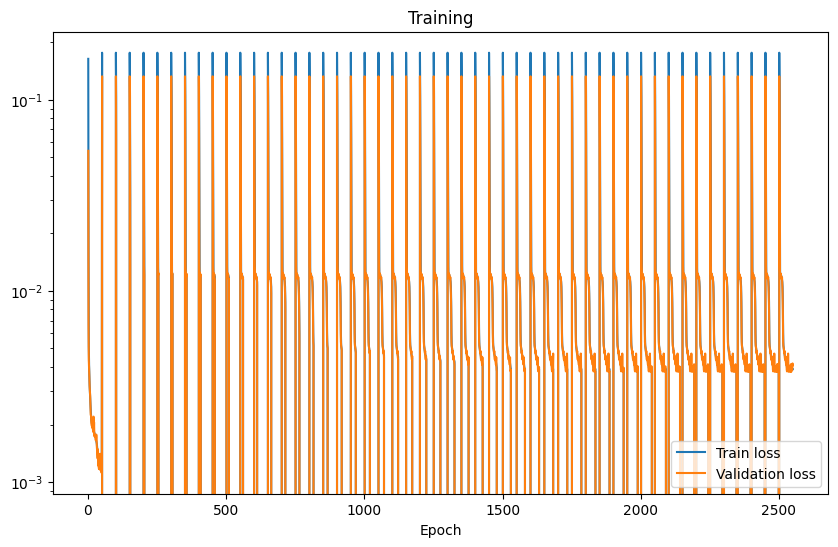

In [14]:
BP_loaded.plot_training()

In [13]:
BP_loaded.train(dataset, resume=True)

Epoch 1: train=0.1764  val=0.1328
Epoch 2: train=0.1040  val=0.0623
Epoch 3: train=0.0303  val=0.0135
Epoch 4: train=0.0125  val=0.0121
Epoch 5: train=0.0123  val=0.0124
Epoch 6: train=0.0122  val=0.0119
Epoch 7: train=0.0121  val=0.0122
Epoch 8: train=0.0120  val=0.0117
Epoch 9: train=0.0119  val=0.0115
Epoch 10: train=0.0117  val=0.0116
Epoch 11: train=0.0115  val=0.0118
Epoch 12: train=0.0111  val=0.0106
Epoch 13: train=0.0105  val=0.0097
Epoch 14: train=0.0087  val=0.0080
Epoch 15: train=0.0060  val=0.0054
Epoch 16: train=0.0052  val=0.0051
Epoch 17: train=0.0050  val=0.0050
Epoch 18: train=0.0049  val=0.0049
Epoch 19: train=0.0048  val=0.0047
Epoch 20: train=0.0047  val=0.0049
Epoch 21: train=0.0046  val=0.0045
Epoch 22: train=0.0045  val=0.0044
Epoch 23: train=0.0044  val=0.0046
Epoch 24: train=0.0044  val=0.0044
Epoch 25: train=0.0043  val=0.0042
Epoch 26: train=0.0043  val=0.0041
Epoch 27: train=0.0042  val=0.0045
Epoch 28: train=0.0041  val=0.0039
Epoch 29: train=0.0040  val=0

/tmp/ipykernel_14018/2209005332.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


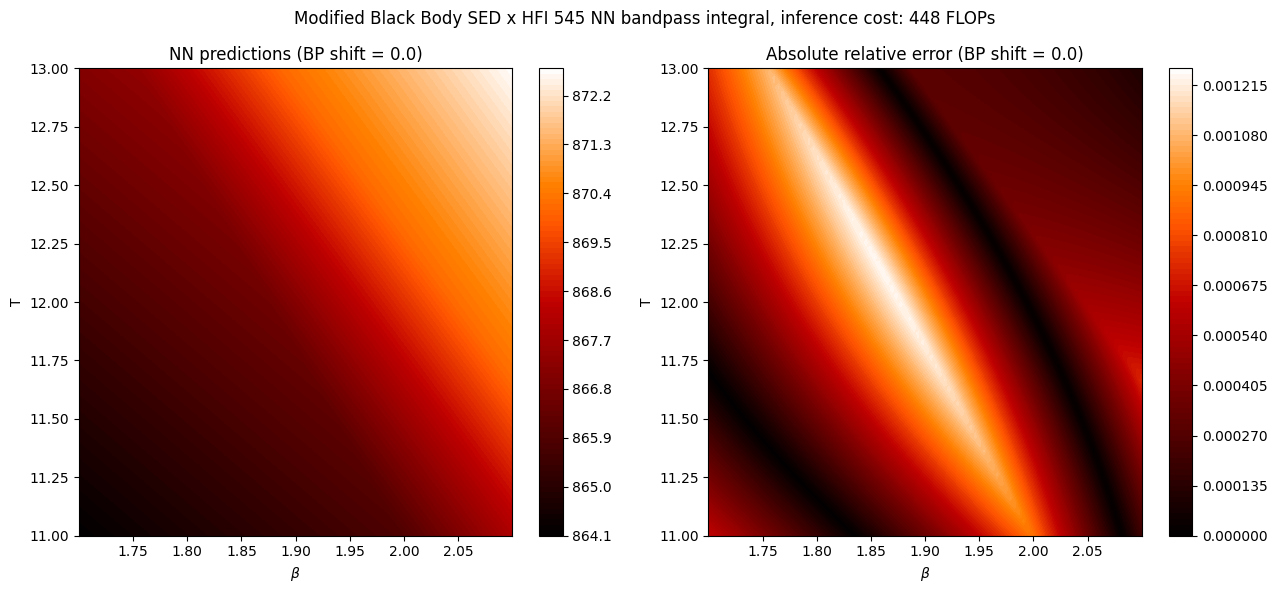

In [15]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s_fixed = 0.0 

grid_b, grid_t = torch.meshgrid(beta_s, t_s, indexing='ij')

X_grid = torch.stack([
    torch.full((N_vals*N_vals,), bp_s_fixed),
    grid_b.flatten(),
    grid_t.flatten()
], dim=1)

# Run in batches to avoid memory issues on large grids
all_true = []
with torch.no_grad():
    preds_grid = BP_loaded.eval(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))
trues_grid=np.array(all_true).reshape((N_vals,N_vals))

#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.flops} FLOPs")
cf = ax[0].contourf(
    grid_b.numpy(),         # x axis  shape: (100, 100)
    grid_t.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel(r'$\beta$')
ax[0].set_ylabel('T')
ax[0].set_title(f'NN predictions (BP shift = {bp_s_fixed})')

cf = ax[1].contourf(
    grid_b.numpy(),       # x axis  shape: (100, 100)
    grid_t.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel(r'$\beta$')
ax[1].set_ylabel('T')
ax[1].set_title(f'Absolute relative error (BP shift = {bp_s_fixed})')
plt.tight_layout()
plt.show()